In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/chest-x-ray-lungs-segmentation'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/chest-x-ray-lungs-segmentation/MetaData.csv
/kaggle/input/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray/mask/1231.png
/kaggle/input/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray/mask/1017.png
/kaggle/input/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray/mask/1522.png
/kaggle/input/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray/mask/1088.png
/kaggle/input/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray/mask/1479.png
/kaggle/input/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray/mask/1684.png
/kaggle/input/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray/mask/1457.png
/kaggle/input/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray/mask/1084.png
/kaggle/input/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray/mask/1680.png
/kaggle/input/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray/mask/1675.png
/kaggle/input/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray/mask/1145.png
/kaggle/input/chest-x-ray-lun

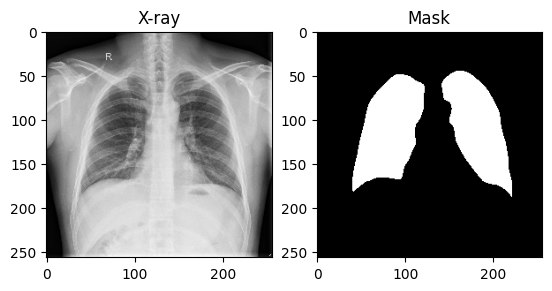

In [2]:
import cv2
import matplotlib.pyplot as plt
from glob import glob

# Paths
image_paths = sorted(glob('/kaggle/input/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray/image/*.png'))
mask_paths = sorted(glob('/kaggle/input/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray/mask/*.png'))

# Resize all to 256x256
IMG_SIZE = 256

def load_image_mask(img_path, mask_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0
    mask = (mask > 0.5).astype('float32')  # binarize
    
    return img.reshape(IMG_SIZE, IMG_SIZE, 1), mask.reshape(IMG_SIZE, IMG_SIZE, 1)

# Example visualization
img, mask = load_image_mask(image_paths[0], mask_paths[0])
plt.subplot(1,2,1)
plt.imshow(img.squeeze(), cmap='gray')
plt.title("X-ray")
plt.subplot(1,2,2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Mask")
plt.show()


In [3]:
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from glob import glob
import os

IMG_SIZE = 256

def load_image_mask(img_path, mask_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    img = img.reshape(IMG_SIZE, IMG_SIZE, 1)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0
    mask = (mask > 0.5).astype('float32')  # Binarize
    mask = mask.reshape(IMG_SIZE, IMG_SIZE, 1)

    return img, mask

# Get image and mask paths
image_paths = sorted(glob('/kaggle/input/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray/image/*.png'))
mask_paths = sorted(glob('/kaggle/input/chest-x-ray-lungs-segmentation/Chest-X-Ray/Chest-X-Ray/mask/*.png'))

# Load all data into arrays
images = []
masks = []

for img_path, mask_path in zip(image_paths, mask_paths):
    img, mask = load_image_mask(img_path, mask_path)
    images.append(img)
    masks.append(mask)

# Convert to numpy arrays
images = np.array(images)
masks = np.array(masks)

# Train/test split
X_train, X_test, Y_train, Y_test = train_test_split(images, masks, test_size=0.2, random_state=42)


In [4]:
from sklearn.model_selection import train_test_split

train_imgs, test_imgs, train_masks, test_masks = train_test_split(image_paths, mask_paths, test_size=0.2, random_state=42)


In [5]:
from tensorflow.keras import layers, models

def unet_model(input_size=(256, 256, 1)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    b = layers.Conv2D(64, 3, activation='relu', padding='same')(b)

    # Decoder
    u2 = layers.UpSampling2D()(b)
    u2 = layers.concatenate([u2, c2])
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(c3)

    u1 = layers.UpSampling2D()(c3)
    u1 = layers.concatenate([u1, c1])
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u1)
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    return models.Model(inputs, outputs)


2025-06-15 15:20:10.653747: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750000810.931674      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750000811.012029      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [6]:
# model = unet_model()
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # Assuming you load all training images/masks into numpy arrays
# # X_train, Y_train = [...], [...]
# model.fit(X_train, Y_train, validation_split=0.1, epochs=5, batch_size=8)


In [7]:
# results = model.evaluate(X_test, Y_test)
# print(f"Test Loss: {results[0]:.4f}")
# print(f"Test Accuracy: {results[1]:.4f}")


In [9]:
model = unet_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, Y_train, validation_split=0.1, epochs=5, batch_size=8)


2025-06-15 15:21:37.128643: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.7194 - loss: 0.5402 - val_accuracy: 0.8550 - val_loss: 0.3277
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.8916 - loss: 0.3122 - val_accuracy: 0.8960 - val_loss: 0.3700
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9050 - loss: 0.2647 - val_accuracy: 0.9291 - val_loss: 0.1953
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9254 - loss: 0.1951 - val_accuracy: 0.9367 - val_loss: 0.1787
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.9343 - loss: 0.1749 - val_accuracy: 0.9454 - val_loss: 0.1420


In [10]:
print(history.history.keys())


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [11]:
results = model.evaluate(X_test, Y_test)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9414 - loss: 0.1516
Test Loss: 0.1580
Test Accuracy: 0.9388


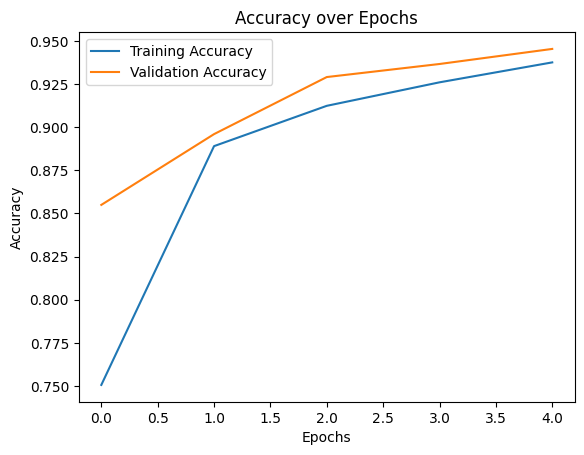

In [12]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


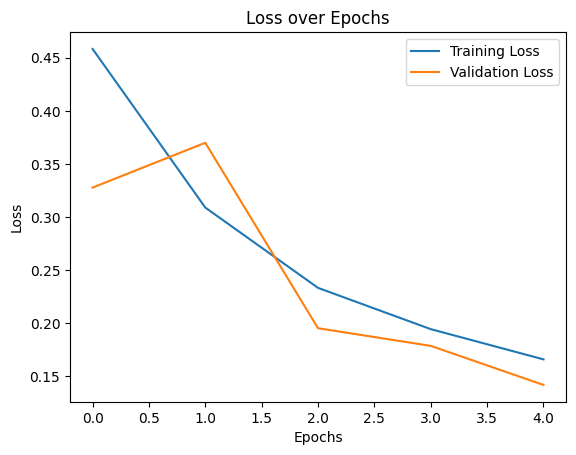

In [13]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


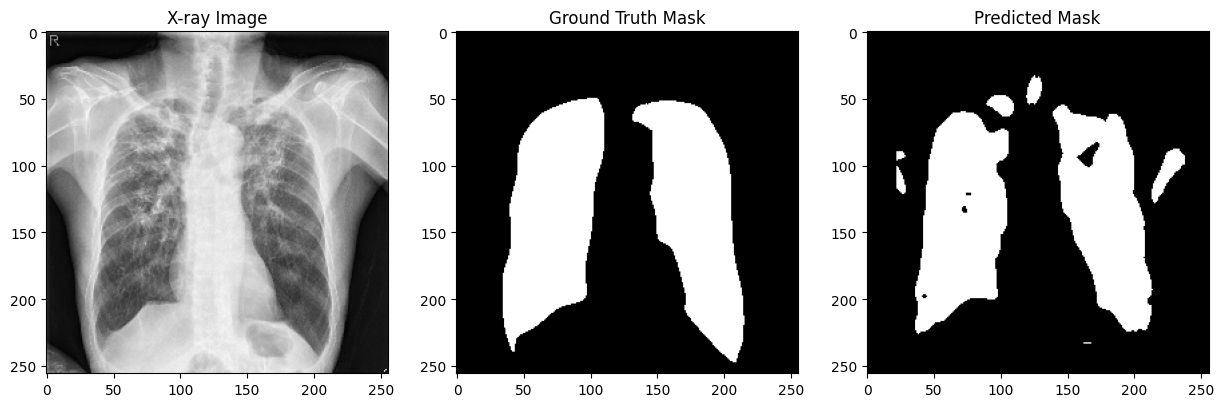

In [15]:
prediction = model.predict(X_test[0:1])[0].squeeze()

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(X_test[0].squeeze(), cmap='gray')
plt.title("X-ray Image")

plt.subplot(1,3,2)
plt.imshow(Y_test[0].squeeze(), cmap='gray')
plt.title("Ground Truth Mask")

plt.subplot(1,3,3)
plt.imshow(prediction > 0.5, cmap='gray')
plt.title("Predicted Mask")
plt.show()
